<a href="https://colab.research.google.com/github/Romfff/ThucHanhDeepLearning/blob/main/Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bước 1: Nạp thư viện -
Bước 2: Đọc và xử lý dữ liệu MNIST -
Bước 3: Trực quan hóa dữ liệu -
Bước 4: Chuyển đổi nhãn sang One-hot Encoding -
Bước 5: Xây dựng cấu trúc mô hình CNN -
Bước 6: Huấn luyện mô hình CNN -
Bước 7: Vẽ đồ thị đánh giá (Độ chính xác & Lỗi) -
Bước 8: Đánh giá mô hình trên tập Test độc lập -
Bước 9: Dự báo thử nghiệm và Lưu mô hình -

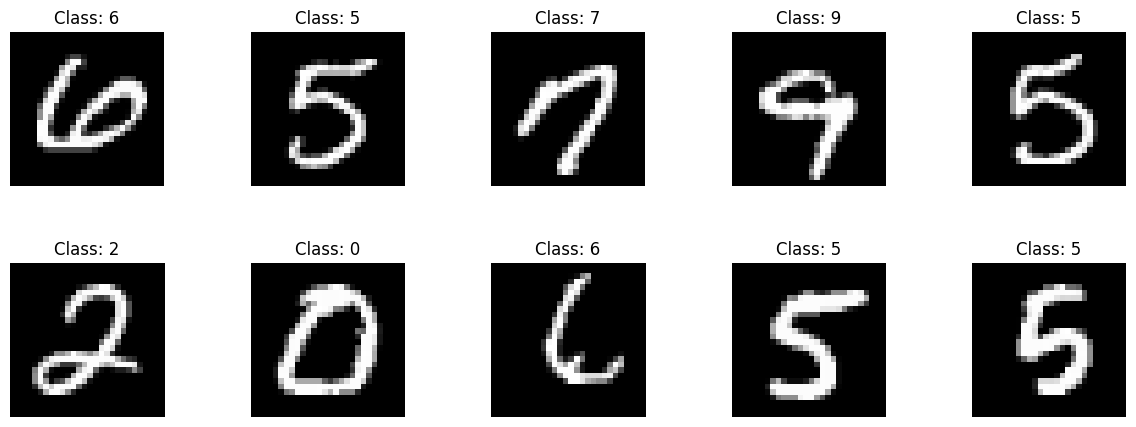

In [3]:
# Hiển thị 10 ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax[i].title.set_text("Class: " + str(y_train[i]))
    ax[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

# Hiển thị bảng tóm tắt kiến trúc mạng
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Quá trình huấn luyện
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.8376 - loss: 0.5962 - val_accuracy: 0.9330 - val_loss: 0.2149
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9551 - loss: 0.1473 - val_accuracy: 0.9580 - val_loss: 0.1381
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.9702 - loss: 0.0980 - val_accuracy: 0.9705 - val_loss: 0.0974
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.9767 - loss: 0.0744 - val_accuracy: 0.9715 - val_loss: 0.0922
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.9818 - loss: 0.0597 - val_accuracy: 0.9745 - val_loss: 0.0790
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9838 - loss: 0.0501 - val_accuracy: 0.9800 - val_loss: 0.0735
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9859 - loss: 0.0449 - val_accuracy: 0.9770 - val_loss: 0.0793
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9893 - loss: 0

In [ ]:
# Đồ thị độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Đồ thị độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('\nTest loss:', score[0])
print('Test accuracy:', score[1])

In [ ]:
# 2.9 Dự báo thử nghiệm một ảnh bất kỳ từ tập test
image_index = 0
plt.imshow(X_test[image_index].reshape(28, 28), cmap='gray')
plt.show()

pred = model.predict(X_test[image_index].reshape(1, 28, 28, 1))
print("Nhãn dự báo từ mô hình CNN:", pred.argmax())

# 2.10 Lưu mô hình xuống file để tái sử dụng
model.save('cnn_mnist_model.h5')
print("Đã lưu mô hình thành công thành file 'cnn_mnist_model.h5'!")

In [4]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [2]:
# Đường dẫn dữ liệu có sẵn trên Google Colab
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

# Đọc dữ liệu bằng pandas
df_train = pd.read_csv(mnist_train, header=None)
df_test = pd.read_csv(mnist_test, header=None)

print("Kích thước tập train:", df_train.shape)

# Tách đặc trưng (X) và nhãn (y)
# Cột đầu tiên (0) là nhãn, các cột sau là pixel ảnh
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("Cấu trúc dữ liệu ban đầu:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Chuẩn hóa dữ liệu về khoảng [0, 1] và Reshape về dạng ảnh (28, 28, 1)
num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("\nCấu trúc dữ liệu sau khi reshape:")
print(X_train.shape, X_test.shape)
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Kích thước tập train: (20000, 785)
Cấu trúc dữ liệu ban đầu:
(20000, 784) (20000,) (10000, 784) (10000,)

Cấu trúc dữ liệu sau khi reshape:
(20000, 28, 28, 1) (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
import matplotlib.pyplot as plt